In [1]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

## The first run of parameter inference with **noise**
*Purpose*: 
- We want to see how much improvement we can get by combining map3 with 2pt.

*Setup*: 
- 2pt chain: this is for comparison. We use public config file available in cosmosis-standard-library `example/des-y3-shear.ini` with some modification.
- 2pt+map3: We add map3 on top of 2pt. We only use auto-correlation of redshift bins (4 combinations), and 4 filter radii for map3 (same filter radii for a map3, i.e. $M_{\rm ap}^3(R_1=R, R_2=R, R_3=R)$).

In [2]:
def get_2pt_samples(wplot=True):
    header = '''cosmological_parameters--omega_m       cosmological_parameters--h0     cosmological_parameters--omega_b        cosmological_parameters--n_s    cosmological_parameters--s_8    shear_calibration_parameters--m1          shear_calibration_parameters--m2        shear_calibration_parameters--m3        shear_calibration_parameters--m4        wl_photoz_errors--bias_1        wl_photoz_errors--bias_2        wl_photoz_errors--bias_3  wl_photoz_errors--bias_4        intrinsic_alignment_parameters--a1      intrinsic_alignment_parameters--alpha1  COSMOLOGICAL_PARAMETERS--SIGMA_8        COSMOLOGICAL_PARAMETERS--SIGMA_12       DATA_VECTOR--2PT_CHI2     prior   like    post    weight'''
    chain = np.loadtxt('../output/des-y3-2pt-sim-CosmoGrid.txt')

    om = chain[:, 0]
    s8 = chain[:, 4]
    sig8= chain[:, -7]
    samples = np.array([om, s8, sig8]).T
    w  = chain[:,-1]
    names = ['om', 's8', 'sig8']
    labels= [r'\Omega_{\rm m}', r'S_8', r'\sigma_8']
    samples = MCSamples(samples=samples, weights=w, names=names, labels=labels)

    if wplot:
        plt.figure(figsize=(4,2))
        plt.plot(w[:-500]) # remove live points for ease of viewing
        plt.show()

    return samples

def get_2ptmap3_samples(wplot=True):
    header = '''cosmological_parameters--omega_m       cosmological_parameters--h0     cosmological_parameters--omega_b        cosmological_parameters--n_s    cosmological_parameters--s_8    shear_calibration_parameters--m1          shear_calibration_parameters--m2        shear_calibration_parameters--m3        shear_calibration_parameters--m4        wl_photoz_errors--bias_1        wl_photoz_errors--bias_2        wl_photoz_errors--bias_3  wl_photoz_errors--bias_4        intrinsic_alignment_parameters--a1      intrinsic_alignment_parameters--alpha1  COSMOLOGICAL_PARAMETERS--SIGMA_8        COSMOLOGICAL_PARAMETERS--SIGMA_12       DATA_VECTOR--2PT_CHI2     prior   like    post    weight'''
    # chain = np.loadtxt('../output/des-y3-2pt-map3-sim-CosmoGrid.txt')
    chain = np.loadtxt('../output/des-y3-2pt-map3-sim-CosmoGrid-syn.txt')

    om = chain[:, 0]
    s8 = chain[:, 4]
    sig8= chain[:, -7]
    w  = chain[:,-1]
    samples = np.array([om, s8, sig8]).T

    names = ['om', 's8', 'sig8']
    labels= [r'\Omega_{\rm m}', r'S_8', r'\sigma_8']
    samples = MCSamples(samples=samples, weights=w, names=names, labels=labels)

    if wplot:
        plt.figure(figsize=(4,2))
        plt.plot(w[:-500]) # remove live points for ease of viewing
        # plt.plot(w[:])
        plt.show()
    
    return samples

Removed no burn in


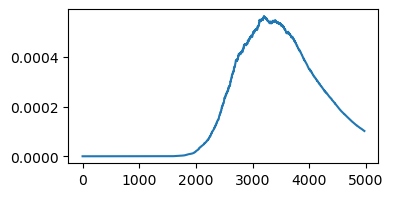

Removed no burn in


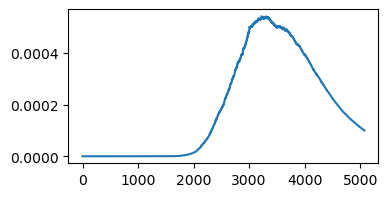

In [3]:
samples_2pt = get_2pt_samples(wplot=True)
samples_2ptmap3  = get_2ptmap3_samples(wplot=True)

<Figure size 600x600 with 0 Axes>

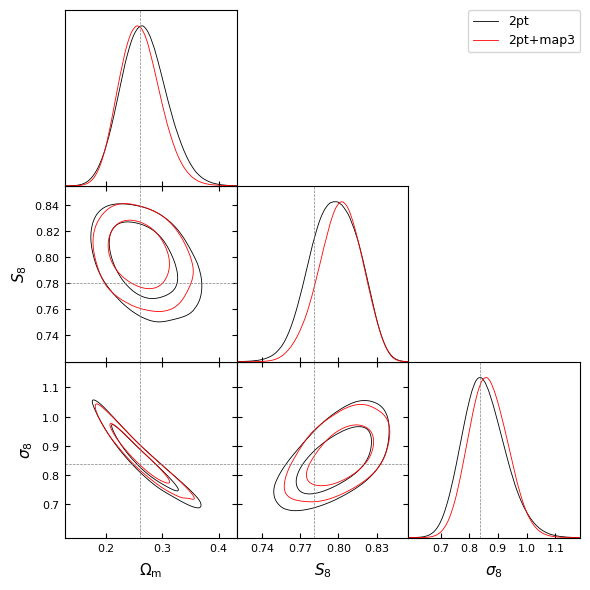

In [4]:
g = plots.get_single_plotter(ratio=1)
g.triangle_plot([samples_2pt, samples_2ptmap3], filled=False, \
    legend_labels=['2pt', '2pt+map3'], legend_loc='upper right', 
    markers={'om': 0.26, 's8': 0.780381, 'sig8': 0.837854})
plt.show()

In [5]:
cov_2pt = samples_2pt.getCov(pars=[0, 2])
cov_2ptmap3= samples_2ptmap3.getCov(pars=[0, 2])

In [6]:
fom_2pt = np.linalg.det(cov_2pt)**-0.5
fom_2ptmap3 = np.linalg.det(cov_2ptmap3)**-0.5

In [7]:
print('FoM of 2pt'.ljust(20) + ': {:.2f}'.format(fom_2pt))
print('FoM of 2pt+map3'.ljust(20) + ': {:.2f}'.format(fom_2ptmap3))
print('FoM ratio'.ljust(20) + ': {:.2f}'.format(fom_2ptmap3/fom_2pt))

FoM of 2pt          : 1139.56
FoM of 2pt+map3     : 1413.30
FoM ratio           : 1.24


# Signal

In [73]:
import pickle
def load_obj(name):
    try:
        with open(name + '.pkl', 'rb') as f:
            return pickle.load(f)
    except:
        with open(name + '.pkl', 'rb') as f:
            return pickle.load(f, encoding='latin1')

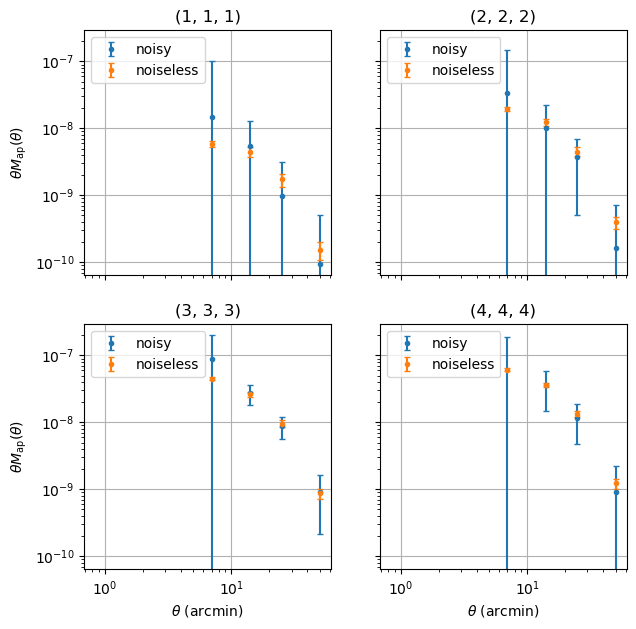

In [75]:
fig, axes = plt.subplots(2,2, figsize=(7,7), sharey=True, sharex=True)
plt.subplots_adjust(hspace=0.2, wspace=0.2)
axes = axes.flatten()
t = np.array([7.0,14.0,25.0,50.0])

obj = load_obj('../data/nz/map3_dv_NOISY_COSMOGRID_29Mar24_REDSHIFT_AUTOCORRELATIONS_ONLY')
for i in range(4):
    ax = axes[i]
    std = np.diag(obj['cov'])**0.5
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid()
    ax.errorbar(t, t*obj['y_obs'][i*4:(i+1)*4], t*std[i*4:(i+1)*4], label='noisy', fmt='.', capsize=2)

obj = load_obj('../data/nz/map3_dv_COSMOGRID_7Mar24_REDSHIFT_AUTOCORRELATIONS_ONLY')
for i in range(4):
    ax = axes[i]
    std = np.diag(obj['cov'])**0.5
    ax.errorbar(t, t*obj['y_obs'][i*4:(i+1)*4], t*std[i*4:(i+1)*4], label='noiseless', fmt='.', capsize=2)
    ax.set_title(f'({i+1}, {i+1}, {i+1})')
    ax.set_xlabel(r'$\theta$ (arcmin)') if i // 2 == 1 else None
    ax.set_ylabel(r'$\theta M_{\rm ap}(\theta)$') if i % 2 == 0 else None
    ax.legend()

plt.show()

## Signal-to-noise ratio

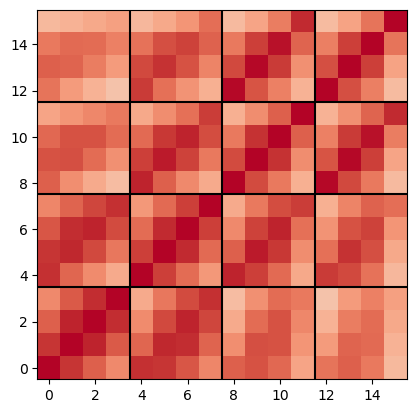

In [110]:
cov = obj['cov']
std = np.diag(cov)**0.5
rcc = cov/np.outer(std, std)
plt.imshow(rcc, cmap='coolwarm', vmin=-1, vmax=1, origin='lower')

for i in range(3):
    plt.axhline(3.5+i*4, color='black', linestyle='-')
    plt.axvline(3.5+i*4, color='black', linestyle='-')

plt.show()

In [111]:
sig = obj['y_obs']
icov= obj['inv_cov']

In [112]:
np.dot(sig, np.dot(icov, sig))**0.5

22.56595189371764